In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full + Chebyshev) ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's aggregate mixture mean +/- 5*std; covers >=96% of
#                 its marginal mass for any distribution.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-2116.00, +2253.07]
  Alt2       [-1431.95, +1491.98]
  Alt3       [-1103.55, +1171.63]
  Price      [-489.80, +318.29]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-12.57, +15.22]
  Alt2       [-8.60, +16.41]
  Alt3       [-6.22, +12.23]
  Price      [-10.54, +5.33]


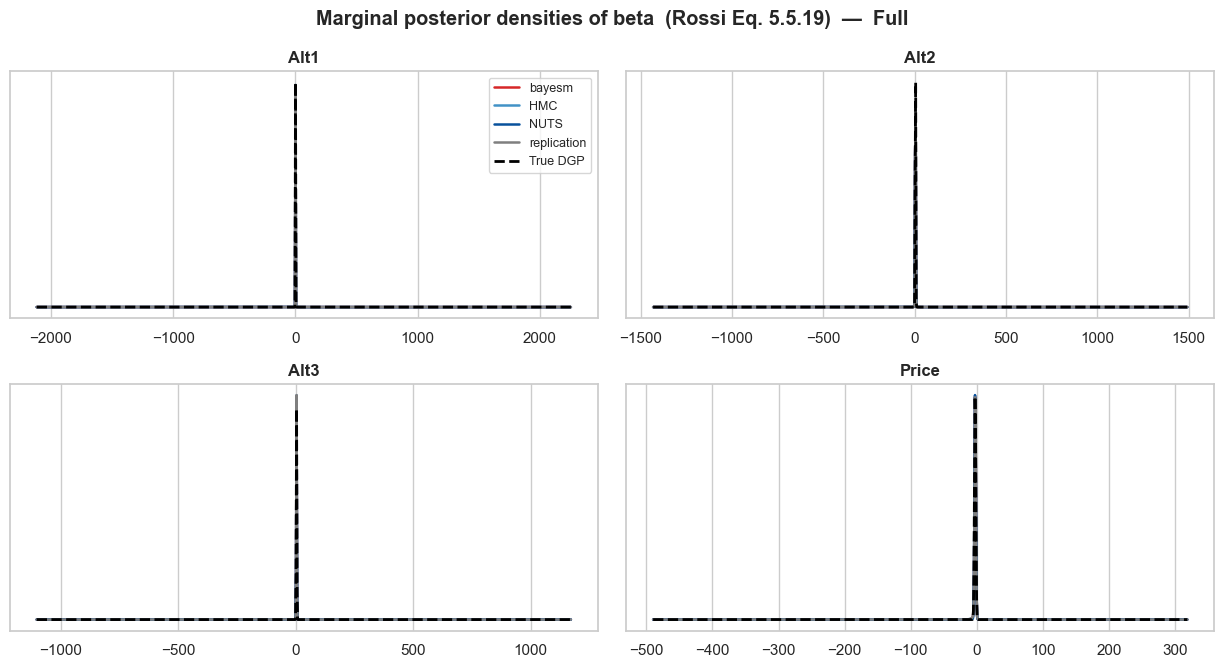

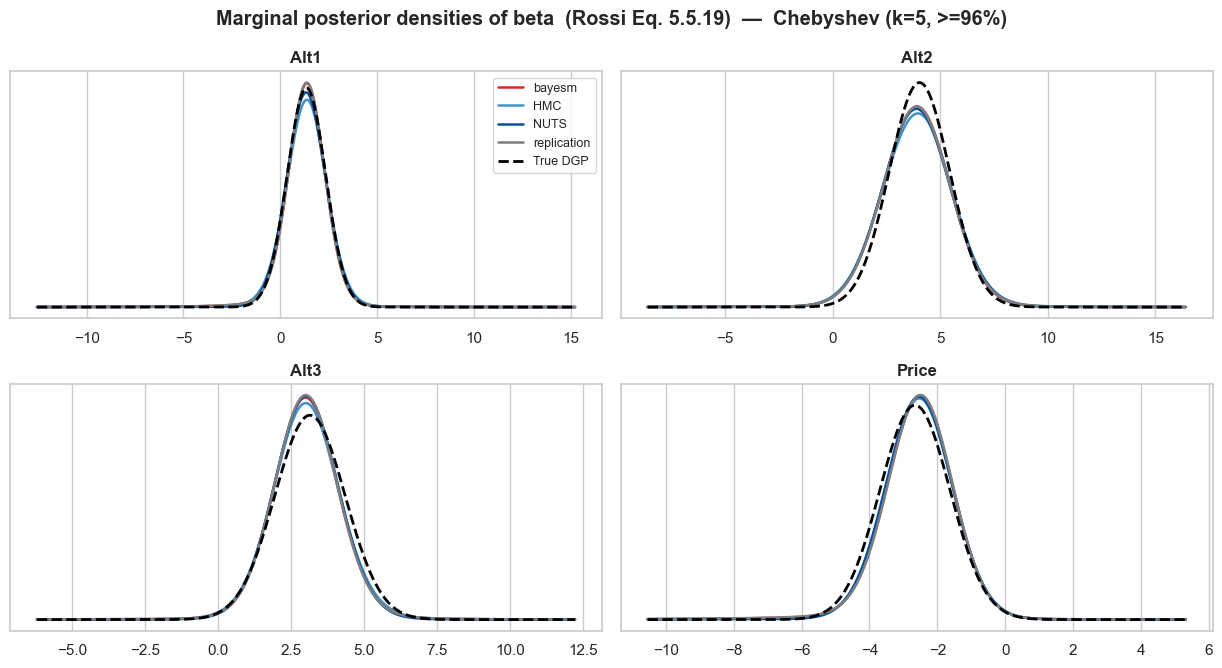

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, Liesel samplers in
# blues. Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:283: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06804  0.16895  0.00349  0.01172       0.06478
            Alt2     0.08114      inf  0.00595  0.07492       0.28071
            Alt3     0.07587  0.15636  0.00499  0.03995       0.13167
            Price    0.09315      inf  0.00714  0.06056       0.17814
HMC         Alt1     0.06992  0.45606  0.00371  0.01260       0.12281
            Alt2     0.09331      inf  0.00761  0.07535       0.33739
            Alt3     0.07561  0.40651  0.00461  0.02956       0.16137
            Price    0.09055      inf  0.00645  0.05341       0.19360
NUTS        Alt1     0.05401  0.38165  0.00217  0.00753       0.08358
            Alt2     0.08683      inf  0.00673  0.08113       0.33171
            Alt3     0.07409  0.28441  0.00478  0.04503       0.14305
            Price    0.07365      inf  0.00445  0.04939       0.15966
replication Alt1     0.07050  0.17746  0.00373  0.01241       0.06775
            Alt2     0.08383      inf  0.00631  0.07635       0.28639
            Alt3     0.08122  0.22089  0.00572  0.04791       0.14035
            Price    0.10061      inf  0.00826  0.06415       0.19141

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.07561  0.14949  0.00449  0.02527       0.06967
            Alt2     0.08078  0.05645  0.00602  0.06577       0.21004
            Alt3     0.07221  0.04854  0.00468  0.06089       0.15248
            Price    0.08388  0.08445  0.00600  0.06352       0.14340
HMC         Alt1     0.07616  0.18309  0.00466  0.03451       0.10749
            Alt2     0.09238  0.07788  0.00783  0.07557       0.23106
            Alt3     0.06525  0.04785  0.00371  0.05167       0.13672
            Price    0.07186  0.07314  0.00434  0.05376       0.13045
NUTS        Alt1     0.05463  0.13016  0.00229  0.01681       0.06471
            Alt2     0.08182  0.05809  0.00624  0.07050       0.21461
            Alt3     0.06557  0.03504  0.00398  0.05947       0.13936
            Price    0.06153  0.04333  0.00331  0.05051       0.12094
replication Alt1     0.07804  0.15111  0.00478  0.02649       0.07331
            Alt2     0.08262  0.06145  0.00625  0.06654       0.21191
            Alt3     0.07515  0.05283  0.00507  0.06345       0.14726
            Price    0.08937  0.09851  0.00678  0.06669       0.14993

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.298,1.326,1.312,1.294,1.349
Alt2,3.870,3.906,3.881,3.887,4.032
Alt3,2.994,3.004,2.996,2.995,3.141
Price,-2.576,-2.606,-2.559,-2.594,-2.659


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.660,7.721,4.868,1.662,0.980
Alt2,3.021,6.258,5.013,3.081,1.974
Alt3,1.911,3.403,2.634,2.094,1.454
Price,1.852,2.518,2.162,2.011,1.063


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 427s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.001  1255.549  3254.336       2.940       7.621
      sd          1.001  1269.126  3379.682       2.972       7.915
      q05         1.006   655.460   854.380       1.535       2.001
      q50         1.001   795.103  1156.082       1.862       2.707
      q95         1.001   583.340  1379.140       1.366       3.230
Alt2  mean        1.002  1265.778  3955.504       2.964       9.263
      sd          1.001  1908.726  3601.102       4.470       8.433
      q05         1.001  2500.658  5879.650       5.856      13.770
      q50         1.001   875.584  1199.547       2.051       2.809
      q95         1.005   644.401  1149.708       1.509       2.693
Alt3  mean        1.002  1047.532  3262.878       2.453       7.641
      sd          1.002   761.469  2658.939       1.783       6.227
      q05         1.003  1046.512  3379.900       2.451       7.915
      q50         1.001  1115.617  2821.355       2.613       6.607
      q95         1.002   327.563   793.490       0.767       1.858
Price mean        1.009   416.484  1849.566       0.975       4.332
      sd          1.010   329.932  2072.420       0.773       4.853
      q05         1.006   343.826   730.047       0.805       1.710
      q50         1.002  1626.268  4910.065       3.809      11.499
      q95         1.002  2564.781  9553.515       6.007      22.374

--- HMC  (fit wall-clock: 447s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.006    96.092    74.068       0.215       0.166
      sd          1.018   109.293    59.780       0.245       0.134
      q05         1.108    15.134   250.694       0.034       0.561
      q50         1.038    66.000   144.591       0.148       0.323
      q95         1.089    21.547   370.612       0.048       0.829
Alt2  mean        1.026   105.508   322.621       0.236       0.722
      sd          1.015   118.320    89.505       0.265       0.200
      q05         1.017   355.991  1278.191       0.796       2.859
      q50         1.074    23.956    89.827       0.054       0.201
      q95         1.045    61.685   360.671       0.138       0.807
Alt3  mean        1.056    37.523   169.566       0.084       0.379
      sd          1.009    96.074   159.265       0.215       0.356
      q05         1.006   233.868   762.914       0.523       1.707
      q50         1.023   141.079   860.274       0.316       1.925
      q95         1.153    10.131    81.350       0.023       0.182
Price mean        1.184     7.700    61.551       0.017       0.138
      sd          1.122    11.248    75.977       0.025       0.170
      q05         1.113    13.469   267.615       0.030       0.599
      q50         1.009   359.403   923.926       0.804       2.067
      q95         1.005   866.531  1568.296       1.939       3.508

--- NUTS  (fit wall-clock: 2,255s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.026  1637.093   108.964       0.726       0.048
      sd          1.115    11.803   123.289       0.005       0.055
      q05         1.041    40.461   139.997       0.018       0.062
      q50         1.000  2176.567  2991.282       0.965       1.327
      q95         1.010  1068.765  2879.328       0.474       1.277
Alt2  mean        1.012  1593.097  2777.287       0.707       1.232
      sd          1.092    14.480   318.031       0.006       0.141
      q05         1.016   393.989  4251.891       0.175       1.886
      q50         1.000  1752.357  2241.581       0.777       0.994
      q95         1.018   823.158  1289.356       0.365       0.572
Alt3  mean        1.011  1832.080  2164.411       0.813       0.960
      sd          1.140     9.845   182.328       0.004       0.081
      q05         1.016   872.914  3758.807       0.387       1.667
      q50         1.000  2200.297  4804.348       0.976       2.131
      q95         1.010   869.511  2013.980       0.386       0.893
Price mean        1.029  1155.871   147.104       0.513       0.065
      sd          1.241     6.111    80.396       0.003       0.036
      q05         1.041    42.767    87.888       0.019       0.039
      q50         1.004  3550.369  7553.954       1.575       3.350
      q95         1.011   537.480  2606.881       0.238       1.156

--- replication  (fit wall-clock: 322s) ---


Rhat  ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                    
Alt1  mean        1.001   764.728   2477.046       2.372       7.683
      sd          1.001   708.416   1323.795       2.197       4.106
      q05         1.003   813.697   1476.183       2.524       4.579
      q50         1.004   725.432   2288.750       2.250       7.099
      q95         1.004   522.831   1379.964       1.622       4.280
Alt2  mean        1.003   631.157   2027.810       1.958       6.290
      sd          1.002  1135.653   4238.700       3.522      13.147
      q05         1.001  2197.659   6049.750       6.817      18.765
      q50         1.001   758.118   2241.685       2.351       6.953
      q95         1.005   485.094   1008.921       1.505       3.129
Alt3  mean        1.003   360.963    681.494       1.120       2.114
      sd          1.006   247.497    197.175       0.768       0.612
      q05         1.001  1138.668   2708.995       3.532       8.403
      q50         1.003   799.828   2679.681       2.481       8.312
      q95         1.006   372.754   1024.304       1.156       3.177
Price mean        1.005   370.086   1089.146       1.148       3.378
      sd          1.004   271.265   1352.847       0.841       4.196
      q05         1.006   246.539    594.194       0.765       1.843
      q50         1.000  1977.742   5805.372       6.134      18.007
      q95         1.001  4017.941  10592.290      12.463      32.854

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
